# Final-layer QK circuit experiments

Interpretability of the **final attention layer** of the lag-detection model
(`sweep_d64_4L_mlp`, 4 layers, 1 head, MLP).

**Score identity (RoPE, split-half).** For query pos $i$, key pos $j$, offset $d=i-j$:
$$\text{score}(i,j)=\tfrac{1}{\sqrt{d_h}}\sum_m\big[A_m\cos(d\theta_m)+B_m\sin(d\theta_m)\big],$$
$$A_m=q_mk_m+q_{m+h}k_{m+h},\quad B_m=q_mk_{m+h}-q_{m+h}k_m,\quad \theta_m=10000^{-2m/d_h}.$$
So the score is a Fourier series in the **offset** alone (for fixed $q,k$); the peak is where the
sinusoids constructively interfere. Convention: lag $L\Rightarrow$ correct offset $L-1$ (prediction is one step ahead).

Experiments here:
1. **Rank** of $W_Q,W_K$ (absolute vs SVD-energy effective rank).
2. **Content-only read-space probe** — is the correct offset recoverable from residual *content* alone (RoPE excluded)?
3. **RoPE-faithful score** — the model's real pre-softmax offset profile, compared to (2).

In [4]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from model_class import AutocorrRoPE
from util import generate_autocorr

device = torch.device('cpu')

# ── config ──
CKPT   = 'models/sweep_d64_4L_mlp.pt'
LAYER, HEAD = 3, 0                 # final layer, single head
T, RHO = 200, 0.9
LAG    = 40
CORRECT_OFFSET = LAG - 1           # 39
QDIM, KDIM = 25, 24                # effective dims (90% SVD energy for Q, K)
Q_START = 140                      # query positions [Q_START, T)
EVAL_OFFSETS = list(range(10, 136))
COMB = [k * LAG - 1 for k in range(1, T // LAG + 1)]   # harmonic teeth: 39, 79, 119, ...

model = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()
print('loaded', CKPT, '| comb teeth (offsets):', COMB)

cpu
loaded models/sweep_d64_4L_mlp.pt | comb teeth (offsets): [39, 79, 119, 159, 199]


## 1. Rank of $W_Q,W_K$

Absolute rank vs *effective* rank (how many singular directions hold 90% / 99% of the energy).

In [5]:
def qk_rank(model, li=-1, hi=0):
    li = li if li >= 0 else model.n_layers + li # -1 as input for li 
    WQ, WK, WV, WO = model.layers[li][hi]
    print(f'layer {li}, head {hi}:')
    for name, W in [('Q', WQ), ('K', WK)]:
        W = W.detach()
        S = torch.linalg.svdvals(W)
        cum = torch.cumsum(S.square(), 0) / S.square().sum()
        r90 = int((cum < 0.90).sum()) + 1
        r99 = int((cum < 0.99).sum()) + 1
        abs_rank = torch.linalg.matrix_rank(W).item()
        print(f'  {name}: absolute_rank={abs_rank}  '
              f'effective_rank(90%)={r90}  effective_rank(99%)={r99}')

qk_rank(model)          # final layer
print()
for li in range(model.n_layers):
    qk_rank(model, li)

layer 3, head 0:
  Q: absolute_rank=64  effective_rank(90%)=25  effective_rank(99%)=38
  K: absolute_rank=64  effective_rank(90%)=24  effective_rank(99%)=38

layer 0, head 0:
  Q: absolute_rank=58  effective_rank(90%)=1  effective_rank(99%)=1
  K: absolute_rank=59  effective_rank(90%)=1  effective_rank(99%)=2
layer 1, head 0:
  Q: absolute_rank=64  effective_rank(90%)=1  effective_rank(99%)=10
  K: absolute_rank=64  effective_rank(90%)=1  effective_rank(99%)=15
layer 2, head 0:
  Q: absolute_rank=64  effective_rank(90%)=10  effective_rank(99%)=29
  K: absolute_rank=64  effective_rank(90%)=4  effective_rank(99%)=22
layer 3, head 0:
  Q: absolute_rank=64  effective_rank(90%)=25  effective_rank(99%)=38
  K: absolute_rank=64  effective_rank(90%)=24  effective_rank(99%)=38


## Shared helpers

Effective read-spaces = top left-singular vectors of $W_Q,W_K$ (directions in **residual** space,
since $h W_Q=(hU)SV^\top$). `final_layer_h` returns the residual entering the final attention
(`resids_post_mlp[LAYER-1]`).

In [6]:
WQ, WK, WV, WO = model.layers[LAYER][HEAD]
UQ = torch.linalg.svd(WQ.detach(), full_matrices=False).U[:, :QDIM]   # (64, QDIM) read-space
UK = torch.linalg.svd(WK.detach(), full_matrices=False).U[:, :KDIM]

@torch.no_grad()
def final_layer_h(n_seqs, seed0):
    seqs = np.stack([generate_autocorr(T, RHO, LAG, seed=seed0 + i) for i in range(n_seqs)])
    x = torch.tensor(seqs, dtype=torch.float32, device=device)
    _, _, _, resids_post_mlp = model(x)
    return resids_post_mlp[LAYER - 1]        # (B,T,64) residual entering final attention

@torch.no_grad()
def coords(n_seqs, seed0):
    h = final_layer_h(n_seqs, seed0)
    return h @ UQ, h @ UK                    # (B,T,QDIM), (B,T,KDIM)

def outer_feats(q_sel, k_sel):
    # flattened outer products; logistic on these == bilinear form q^T W k in read-space
    return torch.einsum('npa,npb->npab', q_sel, k_sel).reshape(-1, QDIM * KDIM).numpy()

def report(name, prof):
    peak = EVAL_OFFSETS[int(np.argmax(prof))]
    teeth = '  '.join(f'{D}:{prof[EVAL_OFFSETS.index(D)]:.3f}' for D in COMB if D in EVAL_OFFSETS)
    print(f'[{name}] peak offset={peak} (correct {CORRECT_OFFSET})   comb -> {teeth}')

## 2. Content-only read-space probe  (RoPE excluded)

For query $i$ and key $j=i-D$, form `outer(q_coords_i, k_coords_j)` and train a logistic probe:
**correct offset (39)** vs **nearby non-comb wrong offsets**. Then score every offset $D$ on held-out
sequences. Offset enters **only through autocorrelated content** here (which residual vectors are paired) —
this isolates the matched-filter/content hypothesis from RoPE.

Expect peaks recurring at the comb teeth $kL-1$ (39, 79, 119).

train acc = 0.986   features (84000, 600)
[content probe] peak offset=39 (correct 39)   comb -> 39:0.978  79:0.842  119:0.523


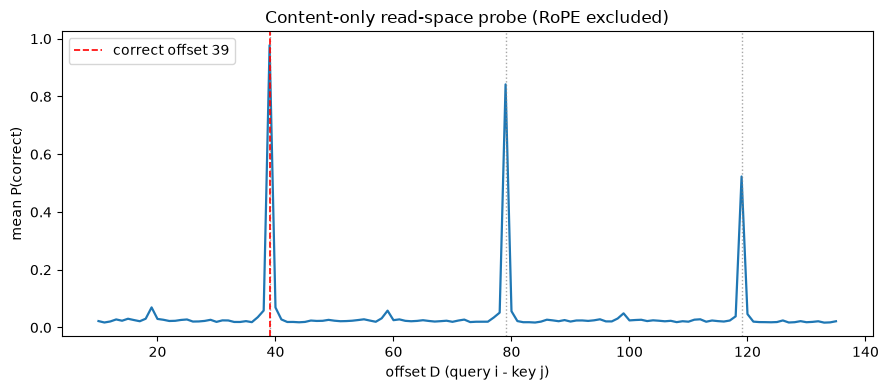

In [7]:
N_TRAIN, N_EVAL = 200, 100
NEG_OFFSETS = [30, 34, 36, 42, 44, 50]   # nearby, non-comb

q_tr, k_tr = coords(N_TRAIN, seed0=0)
q_query = q_tr[:, Q_START:T, :]
X_pos = outer_feats(q_query, k_tr[:, Q_START - CORRECT_OFFSET:T - CORRECT_OFFSET, :])
X_neg = np.concatenate([outer_feats(q_query, k_tr[:, Q_START - D:T - D, :]) for D in NEG_OFFSETS], 0)
X = np.concatenate([X_pos, X_neg], 0)
y = np.concatenate([np.ones(len(X_pos)), np.zeros(len(X_neg))])

scaler = StandardScaler().fit(X)
probe = LogisticRegression(max_iter=3000, C=1.0, class_weight='balanced').fit(scaler.transform(X), y)
print(f'train acc = {probe.score(scaler.transform(X), y):.3f}   features {X.shape}')

q_ev, k_ev = coords(N_EVAL, seed0=100_000)
q_ev_q = q_ev[:, Q_START:T, :]
content_prof = np.array([
    probe.predict_proba(scaler.transform(outer_feats(q_ev_q, k_ev[:, Q_START - D:T - D, :])))[:, 1].mean()
    for D in EVAL_OFFSETS])
report('content probe', content_prof)

plt.figure(figsize=(9, 4))
plt.plot(EVAL_OFFSETS, content_prof, lw=1.6, color='tab:blue')
for D in COMB:
    if D <= EVAL_OFFSETS[-1]: plt.axvline(D, color='grey', ls=':', lw=1, alpha=0.7)
plt.axvline(CORRECT_OFFSET, color='red', ls='--', lw=1.2, label=f'correct offset {CORRECT_OFFSET}')
plt.xlabel('offset D (query i - key j)'); plt.ylabel('mean P(correct)')
plt.title('Content-only read-space probe (RoPE excluded)'); plt.legend(); plt.tight_layout(); plt.show()

loaded


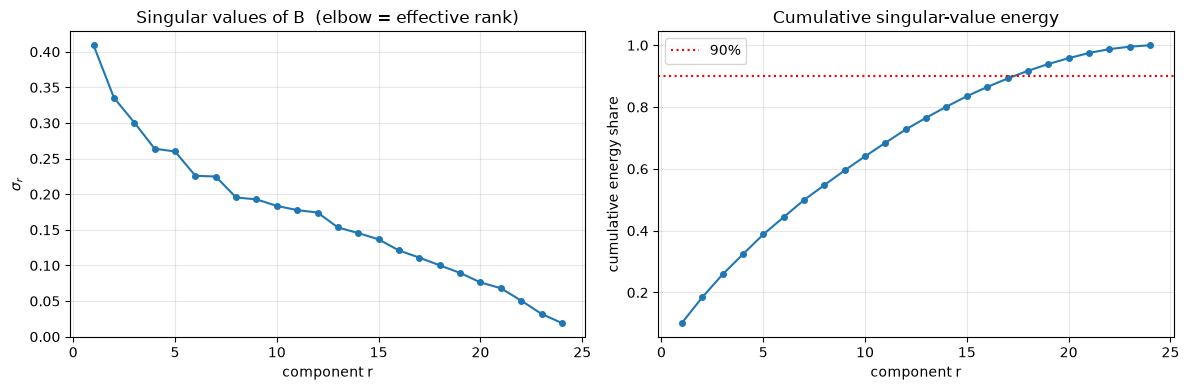

top-1 share 0.101   rank for 90% 18   sigma[:5] [0.4092 0.3354 0.3007 0.2638 0.2601]

 r |    sigma | cos(d_Q, d_K)
------------------------------
 1 |   0.4092 |        +0.184
 2 |   0.3354 |        -0.206
 3 |   0.3007 |        -0.667
 4 |   0.2638 |        +0.107
 5 |   0.2601 |        +0.090


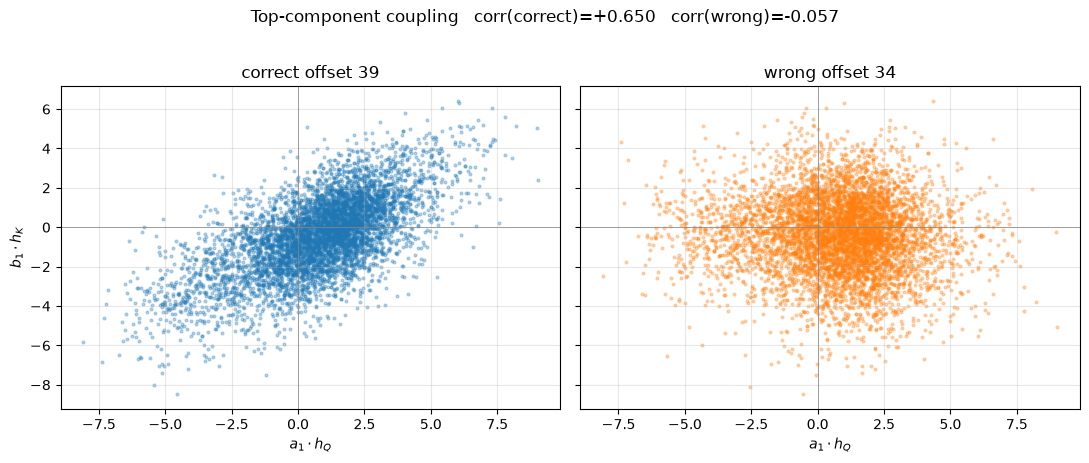

In [8]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch
from model_class import AutocorrRoPE

device = torch.device('cpu')

model = AutocorrRoPE(d_model=64, d_head=64, n_layers=4, n_heads=1, use_mlp=True).to(device)
model.load_state_dict(torch.load('models/sweep_d64_4L_mlp.pt', map_location=device))
model.eval()
print("loaded")
# ── read-space bases (top singular vectors of WQ, WK — residual-side read-in dirs) ──
WQ, WK, WV, WO = model.layers[LAYER][HEAD]
UQ = torch.linalg.svd(WQ.detach(), full_matrices=False).U[:, :QDIM]   # (64, QDIM)
UK = torch.linalg.svd(WK.detach(), full_matrices=False).U[:, :KDIM]   # (64, KDIM)

@torch.no_grad()
def final_layer_h(n_seqs, seed0):
    seqs = np.stack([generate_autocorr(T, RHO, LAG, seed=seed0 + i) for i in range(n_seqs)])
    x = torch.tensor(seqs, dtype=torch.float32, device=device)
    _, _, _, resids_post_mlp = model(x)
    return resids_post_mlp[LAYER - 1]        # (B,T,64) residual entering final attention

@torch.no_grad()
def coords(n_seqs, seed0):
    h = final_layer_h(n_seqs, seed0)
    return h @ UQ, h @ UK                    # (B,T,QDIM), (B,T,KDIM)

def outer_feats(q_sel, k_sel):
    return torch.einsum('npa,npb->npab', q_sel, k_sel).reshape(-1, QDIM * KDIM).cpu().numpy()

def report(name, prof):
    peak = EVAL_OFFSETS[int(np.argmax(prof))]
    teeth = '  '.join(f'{D}:{prof[EVAL_OFFSETS.index(D)]:.3f}' for D in COMB if D in EVAL_OFFSETS)
    print(f'[{name}] peak offset={peak} (correct {CORRECT_OFFSET})   comb -> {teeth}')


# =====================================================================
# Extract B, SVD, elbow, geometry
# =====================================================================

# ---- 1. recover B, undoing the StandardScaler ----
w_scaled = probe.coef_.ravel()
sigma    = scaler.scale_
w_raw    = w_scaled / sigma
B        = w_raw.reshape(QDIM, KDIM)

# ---- 2. SVD + elbow ----
Ua, S, Vt = np.linalg.svd(B)
Vb  = Vt.T
cum = np.cumsum(S) / S.sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.arange(1, len(S)+1), S, marker='o', ms=4)
ax[0].set_xlabel('component r'); ax[0].set_ylabel(r'$\sigma_r$')
ax[0].set_title('Singular values of B  (elbow = effective rank)'); ax[0].grid(alpha=0.3)
ax[1].plot(np.arange(1, len(S)+1), cum, marker='o', ms=4)
ax[1].axhline(0.9, color='r', ls=':', label='90%')
ax[1].set_xlabel('component r'); ax[1].set_ylabel('cumulative energy share')
ax[1].set_title('Cumulative singular-value energy'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

rank90 = int((cum < 0.9).sum() + 1)
print(f"top-1 share {S[0]/S.sum():.3f}   rank for 90% {rank90}   sigma[:5] {np.round(S[:5],4)}")

# ---- 3. map top pairs back to residual space, check symmetry ----
UQ_np = UQ.detach().cpu().numpy()
UK_np = UK.detach().cpu().numpy()

print(f"\n{'r':>2} | {'sigma':>8} | {'cos(d_Q, d_K)':>13}")
print('-'*30)
for r in range(min(5, len(S))):
    d_Q = UQ_np @ Ua[:, r]; d_Q /= np.linalg.norm(d_Q)
    d_K = UK_np @ Vb[:, r]; d_K /= np.linalg.norm(d_K)
    print(f"{r+1:>2} | {S[r]:>8.4f} | {float(d_Q @ d_K):>+13.3f}")

# ---- 4. coupling scatter for the top component: correct vs wrong ----
q_ev, k_ev = coords(N_EVAL, seed0=100_000)
q_ev_q = q_ev[:, Q_START:T, :].reshape(-1, QDIM).cpu().numpy()
a1, b1 = Ua[:, 0], Vb[:, 0]
zq = q_ev_q @ a1

def key_proj(D):
    ksel = k_ev[:, Q_START - D:T - D, :].reshape(-1, KDIM).cpu().numpy()
    return ksel @ b1

zk_correct = key_proj(CORRECT_OFFSET)
zk_wrong   = key_proj(34)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
ax[0].scatter(zq, zk_correct, s=4, alpha=0.3)
ax[0].set_title(f'correct offset {CORRECT_OFFSET}')
ax[1].scatter(zq, zk_wrong, s=4, alpha=0.3, color='tab:orange')
ax[1].set_title('wrong offset 34')
for a in ax:
    a.axhline(0, color='gray', lw=0.5); a.axvline(0, color='gray', lw=0.5)
    a.set_xlabel(r'$a_1\cdot h_Q$'); a.grid(alpha=0.3)
ax[0].set_ylabel(r'$b_1\cdot h_K$')
corr_c = np.corrcoef(zq, zk_correct)[0,1]
corr_w = np.corrcoef(zq, zk_wrong)[0,1]
fig.suptitle(f'Top-component coupling   corr(correct)={corr_c:+.3f}   corr(wrong)={corr_w:+.3f}', y=1.02)
plt.tight_layout(); plt.show()

## 3. RoPE-faithful QK score  vs  content probe

The model's **actual** pre-softmax score, RoPE applied at the real positions:
$\;\text{score}(i,j)=\text{RoPE}(h_iW_Q,i)\cdot\text{RoPE}(h_jW_K,j)/\sqrt{d_h}$, averaged over query
positions vs offset $D$. If (A) and (B) peak together, content and RoPE geometry agree.

[RoPE score] peak offset=39 (correct 39)   comb -> 39:24.028  79:12.631  119:4.490


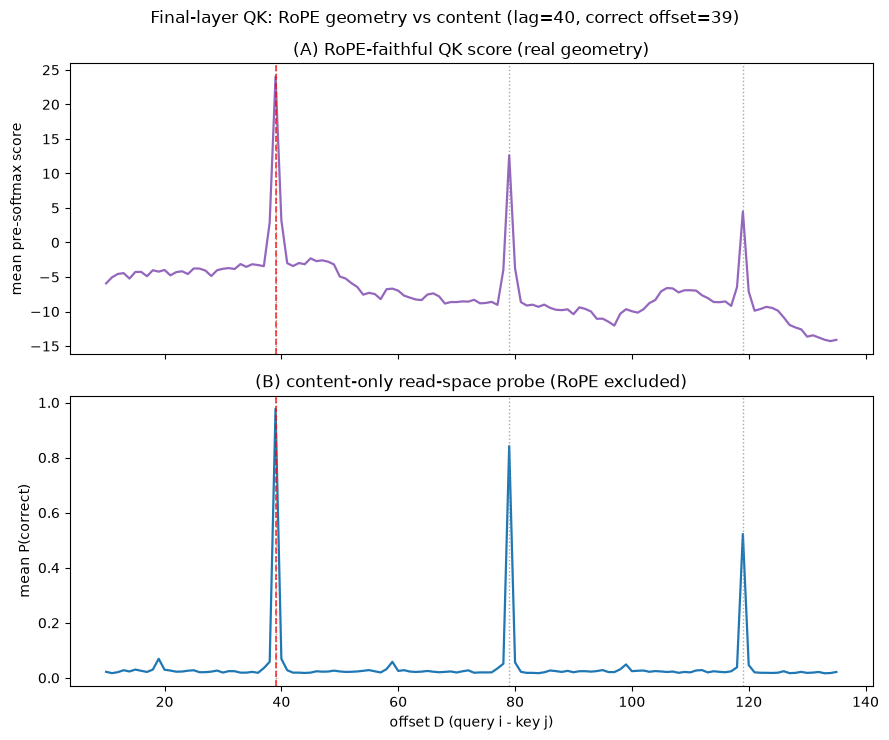

In [9]:
@torch.no_grad()
def rope_score_profile(n_seqs=100, seed0=100_000):
    h = final_layer_h(n_seqs, seed0)
    B = h.shape[0]
    q_head, k_head = h @ WQ, h @ WK
    pos = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
    Qr, Kr = model.apply_rope(q_head, pos), model.apply_rope(k_head, pos)
    scale = math.sqrt(model.d_head)
    q_sel = Qr[:, Q_START:T, :]
    return np.array([((q_sel * Kr[:, Q_START - D:T - D, :]).sum(-1) / scale).mean().item()
                     for D in EVAL_OFFSETS])

rope_prof = rope_score_profile()
report('RoPE score', rope_prof)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7.5), sharex=True)
ax1.plot(EVAL_OFFSETS, rope_prof, lw=1.6, color='tab:purple')
ax1.set_ylabel('mean pre-softmax score'); ax1.set_title('(A) RoPE-faithful QK score (real geometry)')
ax2.plot(EVAL_OFFSETS, content_prof, lw=1.6, color='tab:blue')
ax2.set_ylabel('mean P(correct)'); ax2.set_xlabel('offset D (query i - key j)')
ax2.set_title('(B) content-only read-space probe (RoPE excluded)')
for ax in (ax1, ax2):
    for D in COMB:
        if D <= EVAL_OFFSETS[-1]: ax.axvline(D, color='grey', ls=':', lw=1, alpha=0.7)
    ax.axvline(CORRECT_OFFSET, color='red', ls='--', lw=1.2, alpha=0.8)
fig.suptitle(f'Final-layer QK: RoPE geometry vs content (lag={LAG}, correct offset={CORRECT_OFFSET})')
fig.tight_layout(); plt.show()

### Results (sweep_d64_4L_mlp)
- **Rank:** $W_Q,W_K$ are full rank (64) but effective rank ~24-25 at 90% energy — a compact circuit.
- **Content probe:** train acc ~0.99, peak at offset 39, comb decaying 0.98 -> 0.84 -> 0.51 at 39/79/119.
- **RoPE score:** peak at 39, comb decaying 23.9 -> 12.5 -> 4.2 at 39/79/119.
- **Takeaway:** RoPE geometry and residual content **agree** on the correct offset and its harmonics;
  the attenuating comb mirrors the model's decaying lag-confidence OOD.

_Next: second SVD of the learned probe weight matrix (reshape 600 -> 25x24) to extract the top paired
Q/K read-space directions carrying the discrimination._